In [31]:
# import json
# from pathlib import Path

# import pandas as pd


# INPUT_DIR = Path("education_info")
# OUTPUT_FILE = Path("data/education_people.csv")


# def pascal_case(value):
#     return "".join(part.capitalize() for part in value.split("_"))


# def flatten(value, prefix, row):
#     if isinstance(value, dict):
#         for key, item in value.items():
#             column = f"{prefix}_{pascal_case(key)}" if prefix else pascal_case(key)
#             flatten(item, column, row)
#     elif isinstance(value, list):
#         row[f"{prefix}_Count"] = len(value)
#         for index, item in enumerate(value, start=1):
#             flatten(item, f"{prefix}_{index}", row)
#     else:
#         row[prefix] = value


# rows = []

# for file_path in sorted(INPUT_DIR.glob("*.json")):
#     with file_path.open(encoding="utf-8") as file:
#         document = json.load(file)

#     ticker = file_path.stem.split("_")[0]

#     people = [
#         ("CEO", document.get("ceo")),
#         *[("TMT", person) for person in document.get("tmt") or []],
#     ]

#     for person_type, person in people:
#         if person is None:
#             continue

#         row = {
#             "Ticker": ticker,
#             "Name": person["name"],
#             "PersonType": person_type,
#             "SourceFile": file_path.name,
#         }

#         flatten(
#             {
#                 key: value
#                 for key, value in person.items()
#                 if key not in {"name", "company_name"}
#             },
#             "",
#             row,
#         )

#         rows.append(row)


# df = pd.DataFrame(rows)

# df = (
#     df.drop_duplicates(subset=["Ticker", "Name"], keep="first")
#     .reset_index(drop=True)
# )

# priority_columns = [
#     "Ticker",
#     "Name",
#     "PersonType",
#     "CurrentRole",
#     "HIndex",
#     "Notes",
#     "SourceFile",
# ]

# priority_columns = [
#     column for column in priority_columns
#     if column in df.columns
# ]

# df = df[
#     priority_columns
#     + [column for column in df.columns if column not in priority_columns]
# ]

# df.to_csv(
#     OUTPUT_FILE,
#     index=False,
#     encoding="utf-8-sig",
# )

In [32]:
import json
import re
from pathlib import Path

import pandas as pd


INPUT_DIR = Path("education_info")
OUTPUT_FILE = Path("data/education_people_short.csv")

PROGRAM_KEYS = (
    "program",
    "program_or_specialty",
    "specialty",
    "specialization",
    "field",
    "field_of_study",
    "major",
)


def normalize_key(value):
    return re.sub(r"[^a-z0-9]", "", value.lower())


def get_value(mapping, *names):
    if not isinstance(mapping, dict):
        return None

    normalized = {normalize_key(key): value for key, value in mapping.items()}

    for name in names:
        if normalize_key(name) in normalized:
            return normalized[normalize_key(name)]

    return None


def as_list(value):
    if value in (None, "", [], {}):
        return []
    return value if isinstance(value, list) else [value]


def text_values(value):
    if isinstance(value, list):
        return [
            text
            for item in value
            for text in text_values(item)
        ]

    if value is None or isinstance(value, dict):
        return []

    text = str(value).strip()
    return [text] if text else []


def unique_join(values):
    result = []
    seen = set()

    for value in values:
        key = value.casefold()
        if key not in seen:
            seen.add(key)
            result.append(value)

    return " | ".join(result)


def extract_programs(person):
    programs = []

    records = (
        as_list(get_value(person, "education"))
        + as_list(get_value(person, "degrees"))
    )

    for record in records:
        if not isinstance(record, dict):
            continue

        for key in PROGRAM_KEYS:
            programs.extend(text_values(get_value(record, key)))

    return unique_join(programs)


def extract_h_index(person):
    value = get_value(person, "h_index", "hindex")

    if isinstance(value, dict):
        value = get_value(value, "value", "index", "h_index")

    return value


rows = []

for file_path in sorted(INPUT_DIR.glob("*.json")):
    with file_path.open(encoding="utf-8") as file:
        document = json.load(file)

    ticker = file_path.stem.split("_", 1)[0]

    people = [
        ("CEO", get_value(document, "ceo")),
        *[
            ("TMT", person)
            for person in as_list(get_value(document, "tmt"))
        ],
    ]

    for person_type, person in people:
        if not isinstance(person, dict):
            continue

        name = get_value(person, "name")
        if not name: 
            continue

        education = as_list(get_value(person, "education"))
        degrees = as_list(get_value(person, "degrees"))
        publications = as_list(get_value(person, "publications"))
        research = as_list(
            get_value(person, "research_experience", "researchExperience")
        )
        patents = as_list(get_value(person, "patents"))

        rows.append(
            {
                "Ticker": ticker,
                "Name": name,
                "person_type": person_type,
                "current_role": get_value(
                    person,
                    "current_role",
                    "currentRole",
                ),
                "higher_education": int(bool(education or degrees)),
                "degree": int(bool(degrees)),
                "program": extract_programs(person),
                "publications": len(publications),
                "research_experience": len(research),
                "patents": len(patents),
                "h_index": extract_h_index(person),
                "notes": get_value(person, "notes"),
                "source_file": file_path.name,
            }
        )


columns = [
    "Ticker",
    "Name",
    "person_type",
    "current_role",
    "higher_education",
    "degree",
    "program",
    "publications",
    "research_experience",
    "patents",
    "h_index",
    "notes",
    "source_file",
]

df = pd.DataFrame(rows, columns=columns)

df = (
    df.drop_duplicates(subset=["Ticker", "Name"], keep="first")
    .reset_index(drop=True)
)

OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig",
)

In [33]:
import pandas as pd

df_sentiment = pd.read_csv('data/sentiment.csv')
df_media = pd.read_csv('data/ceo_media_coverage_unique.csv')
df_reward = pd.read_excel('data/Managers_Rewards.xlsx')
df_personality = pd.read_csv('data/MOEXBMI_2024_with_photos_and_face_metrics.csv')
df_education = pd.read_csv('data/education_people_short.csv', low_memory=False)

In [34]:
pd.set_option("display.max_columns", None)

df_education

,Ticker,Name,person_type,current_role,higher_education,degree,program,publications,research_experience,patents,h_index,notes,source_file
0,ABIO,Масюк Сергей Владимирович,CEO,"Генеральный директор ПАО ""Артген""",1,0,NaN,0,0,0,NaN,Вуз и специальность не найдены. Ученая степень...,ABIO_person_info.json
1,ABIO,Исаев Артур Александрович,TMT,"Председатель Совета директоров ПАО ""Артген""",1,1,Деловое администрирование,2,1,1,NaN,Академическая степень и h-index не подтвержден...,ABIO_person_info.json
2,ABIO,Богуславский Дмитрий Эдгардович,TMT,"Член Совета директоров ПАО ""Артген""",1,1,Экономика; тема диссертации об институциональн...,0,1,0,NaN,"Публикации, патенты и h-index не подтверждены....",ABIO_person_info.json
3,ABIO,Деев Роман Вадимович,TMT,"Член Совета директоров ПАО ""Артген""; директор ...",1,1,Медицина | Патологическая анатомия,2,1,0,NaN,Annual report states he is an author of patent...,ABIO_person_info.json
4,ABIO,Исаев Андрей Александрович,TMT,"Член Совета директоров ПАО ""Артген""",1,0,NaN,0,0,0,NaN,"Ученая степень, публикации, патенты и h-index ...",ABIO_person_info.json
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118,ZAYM,Ляшенко Павел Андреевич,TMT,член Совета директоров; генеральный директор О...,1,0,NaN,0,0,0,NaN,Идентичность подтверждена официальным отчетом ...,ZAYM_person_info.json
1119,ZAYM,Борейко Александр Сергеевич,TMT,член Совета директоров; директор по управлению...,1,0,NaN,0,0,0,NaN,Идентичность подтверждена официальным отчетом ...,ZAYM_person_info.json
1120,ZAYM,Матвеева Татьяна Васильевна,TMT,член Совета директоров; директор по правовым в...,1,0,NaN,0,0,0,NaN,Идентичность подтверждена официальным отчетом ...,ZAYM_person_info.json
1121,ZAYM,Родионов Станислав Николаевич,TMT,член Совета директоров; директор по информацио...,1,0,NaN,0,0,0,NaN,Идентичность подтверждена официальным отчетом ...,ZAYM_person_info.json


In [35]:
import re
import unicodedata

import numpy as np
import pandas as pd
from rapidfuzz import fuzz
from scipy.optimize import linear_sum_assignment
from unidecode import unidecode


TICKER_ALIASES = {
    "YNDX": "YDEX",
    "T": "TCSG",
    "HNFG": "HEAD",
}

TRANSLIT_ALIASES = {
    "alexey": "aleksei",
    "aleksey": "aleksei",
    "alexei": "aleksei",
    "sergey": "sergei",
    "andrey": "andrei",
    "dmitry": "dmitrii",
    "dmitriy": "dmitrii",
    "dmitri": "dmitrii",
    "yevgeniy": "evgenii",
    "evgeniy": "evgenii",
    "yevgeny": "evgenii",
    "evgeny": "evgenii",
    "eugene": "evgenii",
    "yuri": "iurii",
    "yuriy": "iurii",
    "yurii": "iurii",
    "iuri": "iurii",
    "pyotr": "petr",
    "piotr": "petr",
    "nikolay": "nikolai",
    "ilya": "ilia",
    "mihail": "mikhail",
    "artyom": "artem",
    "gennady": "gennadii",
    "gennadiy": "gennadii",
    "valery": "valerii",
    "valeriy": "valerii",
    "vitaly": "vitalii",
    "vitaliy": "vitalii",
    "anatoliy": "anatolii",
    "anatoly": "anatolii",
    "yulia": "iuliia",
    "yuliya": "iuliia",
    "julia": "iuliia",
    "natalia": "nataliia",
    "natalya": "nataliia",
    "maria": "mariia",
    "mariya": "mariia",
}

PATRONYMIC_RE = re.compile(
    r"(?:ovich|evich|ich|ovna|evna|ichna|kyzy|ogly|oglu)$"
)


def canonical_ticker(value):
    if pd.isna(value):
        return pd.NA

    parts = [
        part.strip().upper()
        for part in re.split(
            r"[,;/|]+",
            str(value).replace("\xa0", " "),
        )
        if part.strip()
    ]

    parts = list(
        dict.fromkeys(TICKER_ALIASES.get(part, part) for part in parts)
    )

    return parts[0] if len(parts) == 1 else ", ".join(parts)


def clean_name(value):
    if pd.isna(value):
        return pd.NA

    value = unicodedata.normalize("NFKC", str(value))
    value = value.replace("\xa0", " ")
    value = re.sub(r"\s+", " ", value).strip()

    return value or pd.NA


def prepare(df):
    df = df.copy()
    df["Ticker"] = df["Ticker"].map(canonical_ticker)

    if "Name" in df.columns:
        df["Name"] = df["Name"].map(clean_name)

    return df


def name_alternatives(value):
    if pd.isna(value):
        return []

    value = clean_name(value)

    variants = [value]
    variants += re.split(r"\s*/\s*", value)
    variants += re.findall(r"\(([^()]*)\)", value)
    variants.append(re.sub(r"\s*\([^()]*\)\s*", " ", value))

    result = []

    for variant in variants:
        variant = re.sub(
            r"^\s*(likely|possibly|вероятно)\s+",
            "",
            variant,
            flags=re.I,
        )
        variant = variant.replace("ё", "е").replace("Ё", "Е")
        variant = re.sub(
            r"[^\w\s.'’-]",
            " ",
            variant,
            flags=re.UNICODE,
        )
        variant = re.sub(r"\s+", " ", variant).strip(" .-/")

        if variant and variant not in result:
            result.append(variant)

    return result


def normalized_tokens(value):
    value = unidecode(value).lower()
    value = value.replace("'", "").replace("`", "")
    value = re.sub(r"[^a-z0-9\s]", " ", value)
    tokens = re.sub(r"\s+", " ", value).strip().split()

    return [
        TRANSLIT_ALIASES.get(token, token)
        for token in tokens
    ]


def strict_name_key(value):
    return " ".join(sorted(normalized_tokens(value)))


def core_tokens(value):
    tokens = normalized_tokens(value)

    if len(tokens) >= 3:
        without_patronymic = [
            token
            for token in tokens
            if not PATRONYMIC_RE.search(token)
        ]

        if len(without_patronymic) >= 2:
            tokens = without_patronymic

    return tokens


def token_similarity(left, right):
    if len(left) == 1 or len(right) == 1:
        return 100 if left[0] == right[0] else 0

    return fuzz.ratio(left, right)


def alternative_score(left, right):
    left_tokens = core_tokens(left)
    right_tokens = core_tokens(right)

    if not left_tokens or not right_tokens:
        return 0.0

    matrix = np.array([
        [
            token_similarity(left_token, right_token)
            for right_token in right_tokens
        ]
        for left_token in left_tokens
    ])

    row_indices, column_indices = linear_sum_assignment(-matrix)

    pair_scores = sorted(
        matrix[row_indices, column_indices],
        reverse=True,
    )

    top_two = np.mean(pair_scores[:min(2, len(pair_scores))])

    coverage = (
        sum(score >= 65 for score in pair_scores)
        / min(len(left_tokens), len(right_tokens))
    )

    left_text = " ".join(left_tokens)
    right_text = " ".join(right_tokens)

    return max(
        fuzz.token_set_ratio(left_text, right_text),
        fuzz.token_sort_ratio(left_text, right_text),
        0.8 * top_two + 20 * coverage,
    )


def name_score(left, right):
    return max(
        (
            alternative_score(left_variant, right_variant)
            for left_variant in name_alternatives(left)
            for right_variant in name_alternatives(right)
        ),
        default=0.0,
    )


def align_education(education, canonical_people, threshold=80):
    education = education.copy()

    canonical_people = (
        canonical_people
        .dropna(subset=["Ticker", "Name"])
        .drop_duplicates()
    )

    education["_education_name"] = education["Name"]
    education["_canonical_name"] = pd.NA
    education["_match_type"] = "unmatched"
    education["_match_score"] = np.nan

    exact_lookup = {}

    for row in canonical_people.itertuples(index=False):
        for alternative in name_alternatives(row.Name):
            key = (row.Ticker, strict_name_key(alternative))
            exact_lookup.setdefault(key, row.Name)

    for index, row in education.iterrows():
        for alternative in name_alternatives(row["Name"]):
            key = (row["Ticker"], strict_name_key(alternative))

            if key in exact_lookup:
                education.at[index, "_canonical_name"] = exact_lookup[key]
                education.at[index, "_match_type"] = "exact"
                education.at[index, "_match_score"] = 100.0
                break

    unmatched = education[education["_canonical_name"].isna()]

    for ticker, group in unmatched.groupby("Ticker"):
        already_matched = set(
            education.loc[
                education["Ticker"].eq(ticker)
                & education["_canonical_name"].notna(),
                "_canonical_name",
            ]
        )

        candidates = (
            canonical_people.loc[
                canonical_people["Ticker"].eq(ticker)
                & ~canonical_people["Name"].isin(already_matched),
                "Name",
            ]
            .drop_duplicates()
            .tolist()
        )

        education_indices = group.index.tolist()

        if not candidates:
            continue

        scores = np.array([
            [
                name_score(
                    education.at[index, "_education_name"],
                    candidate,
                )
                for candidate in candidates
            ]
            for index in education_indices
        ])

        row_indices, column_indices = linear_sum_assignment(-scores)

        for row_index, column_index in zip(
            row_indices,
            column_indices,
        ):
            score = scores[row_index, column_index]

            if score < threshold:
                continue

            index = education_indices[row_index]

            education.at[index, "_canonical_name"] = (
                candidates[column_index]
            )
            education.at[index, "_match_type"] = "fuzzy"
            education.at[index, "_match_score"] = round(
                float(score),
                2,
            )

    match_report = education[
        [
            "Ticker",
            "_education_name",
            "_canonical_name",
            "_match_type",
            "_match_score",
        ]
    ].rename(
        columns={
            "_education_name": "EducationName",
            "_canonical_name": "CanonicalName",
            "_match_type": "MatchType",
            "_match_score": "MatchScore",
        }
    )

    matched_education = education[
        education["_canonical_name"].notna()
    ].copy()

    matched_education["Name"] = matched_education["_canonical_name"]

    matched_education = matched_education.drop(
        columns=[
            "_education_name",
            "_canonical_name",
            "_match_type",
            "_match_score",
        ]
    )

    matched_education = (
        matched_education
        .groupby(
            ["Ticker", "Name"],
            as_index=False,
            dropna=False,
            sort=False,
        )
        .first()
    )

    return matched_education, match_report


def collapse_people(df):
    return (
        df.groupby(
            ["Ticker", "Name"],
            as_index=False,
            dropna=False,
            sort=False,
        )
        .first()
    )


df_sentiment = prepare(df_sentiment)
df_media = collapse_people(prepare(df_media))
df_reward = collapse_people(prepare(df_reward))
df_personality = collapse_people(prepare(df_personality))
df_education = prepare(df_education)

df_sentiment = (
    df_sentiment
    .groupby("Ticker", as_index=False, dropna=False, sort=False)
    .first()
)

canonical_people = (
    pd.concat(
        [
            df_media[["Ticker", "Name"]],
            df_reward[["Ticker", "Name"]],
            df_personality[["Ticker", "Name"]],
        ],
        ignore_index=True,
    )
    .dropna(subset=["Ticker", "Name"])
    .drop_duplicates()
)

df_education, education_match_report = align_education(
    df_education,
    canonical_people,
    threshold=80,
)

dropped_education = (
    education_match_report[
        education_match_report["MatchType"].eq("unmatched")
    ]
    .sort_values(["Ticker", "EducationName"])
    .reset_index(drop=True)
)

base_without_education = (
    canonical_people
    .merge(
        df_education[["Ticker", "Name"]].drop_duplicates(),
        on=["Ticker", "Name"],
        how="left",
        indicator=True,
    )
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
    .sort_values(["Ticker", "Name"])
    .reset_index(drop=True)
)

df_merged = (
    df_personality
    .merge(
        df_media,
        on=["Ticker", "Name"],
        how="outer",
        suffixes=("", "_media"),
    )
    .merge(
        df_reward,
        on=["Ticker", "Name"],
        how="outer",
        suffixes=("", "_reward"),
    )
    .merge(
        df_education,
        on=["Ticker", "Name"],
        how="left",
        suffixes=("", "_education"),
    )
    .merge(
        df_sentiment,
        on="Ticker",
        how="left",
        suffixes=("", "_sentiment"),
    )
)

education_match_report.to_csv(
    "data/education_name_matches.csv",
    index=False,
    encoding="utf-8-sig",
)

dropped_education.to_csv(
    "data/dropped_education_people.csv",
    index=False,
    encoding="utf-8-sig",
)

base_without_education.to_csv(
    "data/people_without_education.csv",
    index=False,
    encoding="utf-8-sig",
)

df_merged.to_csv(
    "data/merged_data.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Итоговый датафрейм:", df_merged.shape)
print("\nСопоставление education:")
print(education_match_report["MatchType"].value_counts())
print("\nУдалено людей только из education:", len(dropped_education))
print("Людей без записи в education:", len(base_without_education))

display(dropped_education)
display(base_without_education)

Итоговый датафрейм: (1119, 72)

Сопоставление education:
MatchType
exact        968
fuzzy        146
unmatched      9
Name: count, dtype: int64

Удалено людей только из education: 9
Людей без записи в education: 4


,Ticker,EducationName,CanonicalName,MatchType,MatchScore
0,IVAT,Иодковский Станислав Эрикович,<NA>,unmatched,NaN
1,MGNT,Евгений Сергеевич Случевский,<NA>,unmatched,NaN
2,MSRS,Александр Михайлович Пятигор,<NA>,unmatched,NaN
3,MTLR,Коржов Олег Викторович,<NA>,unmatched,NaN
4,PHOR,Рыбников Михаил Константинович,<NA>,unmatched,NaN
5,QIWI,Alexey Sergeevich Mashchenkov / Алексей Мащенков,<NA>,unmatched,NaN
6,SGZH,Александр Михайлович Крещенко,<NA>,unmatched,NaN
7,SOFL,Владимир Евгеньевич Лавров,<NA>,unmatched,NaN
8,SPBE,Evgeny Serdyukov,<NA>,unmatched,NaN


,Ticker,Name
0,IVAT,Иодковский Эдмунд Феликсович
1,NVTK,Леонид Михельсон
2,PRMD,Александр Ефремов
3,SGZH,Artem Zasursky


In [36]:
df_merged

,Ticker,Name,Company,Position,Comment,Unnamed: 5,Unnamed: 6,photo_path,collect_photo,face_status,n_faces,face_width_px,face_height_px,eye_tilt_deg,frontal_asymmetry,mouth_open_ratio,face_quality_ok,fwhr_kamiya_brow,fwhr_jia_eyelid,eyebrow_inner_angle_approx,face_roundness_angle_approx,chin_angle_approx,philtrum_ratio,fwhr_kamiya_brow_z,fwhr_jia_eyelid_z,eyebrow_reverse_z,face_roundness_z,chin_angle_z,philtrum_reverse_z,facial_trust_appearance_proxy,Unnamed: 0,Company_media,Position_media,Comment_media,Unnamed: 5_media,Unnamed: 6_media,name_cyrillic,company_clean,yandex_count,name_from_yandex,Company_reward,Position_reward,Comment_reward,Nom_2024,Nom_2023,Nom_2022,Nom_2021,Nom_2020,Nom_2019,Nom_2018,Nom_2017,Nom_2016,Nom_2015,person_type,current_role,higher_education,degree,program,publications,research_experience,patents,h_index,notes,source_file,Unnamed: 0_sentiment,Company_sentiment,Обращение директора,Автор обращения,Тональность,neutral,positive,negative
0,ABIO,Александров Дмитрий Андреевич,"ПАО ""Артген""",Член СД,None,None,None,/Users/mikhalexx/Desktop/LAB/Научная инициатив...,True,ok,1,192.0,193.0,-0.693060,0.239121,0.042853,True,1.718317,1.837345,152.318594,139.771734,152.268920,0.188026,-1.078048,-1.912077,0.169403,1.571072,-0.083998,0.178534,0.458753,556,"ПАО ""Артген""",Член СД,None,None,None,Александров Дмитрий Андреевич,ПАО Артген,722.0,Александров Дмитрий Андреевич,"ПАО ""Артген""",Член СД,None,None,None,None,None,None,None,None,None,None,None,TMT,Член СД по CSV; не подтвержден как член Совета...,1.0,1.0,Биоорганическая химия / химические науки,0.0,1.0,0.0,NaN,Критическая оговорка: CSV относит Александрова...,ABIO_person_info.json,0,"ПАО ""Артген""","Несмотря на сложные внешние условия, 2024 год ...",Генеральный директор,1.0,0.442098,0.545385,0.012517
1,ABIO,Богуславский Дмитрий Эдгардович,"ПАО ""Артген""",Член СД,None,None,None,/Users/mikhalexx/Desktop/LAB/Научная инициатив...,True,ok,1,160.0,161.0,-8.583621,0.151221,0.025833,True,1.784255,1.902432,155.715572,139.281241,157.670240,0.182231,-0.541484,-1.494495,-0.273102,1.442953,1.461466,0.345545,0.744215,765,"ПАО ""Артген""",Член СД,None,None,None,Богуславский Дмитрий Эдгардович,ПАО Артген,385.0,Богуславский Дмитрий Эдгардович,"ПАО ""Артген""",Член СД,None,None,None,None,None,None,None,None,None,None,None,TMT,"Член Совета директоров ПАО ""Артген""",1.0,1.0,Экономика; тема диссертации об институциональн...,0.0,1.0,0.0,NaN,"Публикации, патенты и h-index не подтверждены....",ABIO_person_info.json,0,"ПАО ""Артген""","Несмотря на сложные внешние условия, 2024 год ...",Генеральный директор,1.0,0.442098,0.545385,0.012517
2,ABIO,Деев Роман Вадимович,"ПАО ""Артген""",Член СД,None,None,None,/Users/mikhalexx/Desktop/LAB/Научная инициатив...,True,ok,1,161.0,161.0,7.140514,0.138998,0.014605,True,1.874228,2.233976,155.854082,134.086163,159.645901,0.178235,0.190658,0.632623,-0.291145,0.085972,2.026756,0.460696,0.570570,599,"ПАО ""Артген""",Член СД,None,None,None,Деев Роман Вадимович,ПАО Артген,622.0,Деев Роман Вадимович,"ПАО ""Артген""",Член СД,None,None,None,None,None,None,None,None,None,None,None,TMT,"Член Совета директоров ПАО ""Артген""; директор ...",1.0,1.0,Медицина | Патологическая анатомия,2.0,1.0,0.0,NaN,Annual report states he is an author of patent...,ABIO_person_info.json,0,"ПАО ""Артген""","Несмотря на сложные внешние условия, 2024 год ...",Генеральный директор,1.0,0.442098,0.545385,0.012517
3,ABIO,Исаев Андрей Александрович,"ПАО ""Артген""",Член СД,None,None,None,/Users/mikhalexx/Desktop/LAB/Научная инициатив...,True,quality_check_failed,1,277.0,277.0,1.763986,0.372307,0.127479,False,1.876989,2.343353,141.071099,136.855833,153.606276,0.112874,0.213124,1.334367,NaN,NaN,NaN,NaN,NaN,301,"ПАО ""Артген""",Член СД,None,None,None,Исаев Андрей Александрович,ПАО Артген,1543.0,Исаев Андрей Александрович,"ПАО ""Артген""",Член СД,None,None,None,None,None,None,None,None,None,None,None,TMT,"Член Совета директоров ПАО ""Артген""",1.0,0.0,None,0.0,0.0,0.0,NaN,"Ученая степень, пуб

In [37]:
from pathlib import Path

import numpy as np
import pandas as pd


INPUT_FILE = Path("data/merged_data.csv")
PREPARED_FILE = Path("data/merged_data_prepared.csv")
INDEX_FILE = Path("data/company_reputation_index.csv")


def normalize_text(series: pd.Series) -> pd.Series:
    return (
        series.fillna("")
        .astype(str)
        .str.casefold()
        .str.replace("ё", "е", regex=False)
        .str.replace(r"[^a-zа-я0-9]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


def log_capped_score(series: pd.Series, quantile: float = 0.99) -> pd.Series:
    """
    Преобразует неотрицательный показатель в шкалу 0–1:
    1. log(1 + x);
    2. ограничение на 99-м процентиле;
    3. деление на значение 99-го процентиля.
    """
    values = pd.to_numeric(series, errors="coerce").fillna(0).clip(lower=0)
    transformed = np.log1p(values)

    positive = transformed[transformed > 0]
    if positive.empty:
        return pd.Series(0.0, index=series.index)

    upper_bound = positive.quantile(quantile)
    return (transformed / upper_bound).clip(0, 1)


def positive_log_score(series: pd.Series) -> pd.Series:
    """
    Нулевые значения получают 0 баллов.
    Положительные значения логарифмируются и приводятся к шкале 0–1.
    """
    values = pd.to_numeric(series, errors="coerce").fillna(0).clip(lower=0)
    result = pd.Series(0.0, index=series.index)

    positive_mask = values > 0
    if positive_mask.any():
        transformed = np.log1p(values.loc[positive_mask])
        result.loc[positive_mask] = transformed / transformed.max()

    return result


def observed_minmax_score(series: pd.Series) -> pd.Series:
    """
    NA получает 0 баллов.
    Наблюдаемые значения преобразуются в шкалу 0–1.
    """
    values = pd.to_numeric(series, errors="coerce")
    observed = values.dropna()
    result = pd.Series(0.0, index=series.index)

    if observed.empty or observed.max() == observed.min():
        return result

    mask = values.notna()
    result.loc[mask] = (
        (values.loc[mask] - observed.min())
        / (observed.max() - observed.min())
    )

    return result.clip(0, 1)


df = pd.read_csv(INPUT_FILE)

# Идентификатор человека.
person_name = df["name_cyrillic"].fillna("").astype(str).str.strip()
person_name = person_name.mask(person_name.eq(""), df["Name"])

df["person_id"] = normalize_text(person_name)

# Пустые имена не должны объединяться в одного человека.
empty_person = df["person_id"].eq("")
df.loc[empty_person, "person_id"] = (
    "_unknown_person_" + df.index[empty_person].astype(str)
)

# Тикер используется как идентификатор компании.
df["company_id"] = df["Ticker"].fillna("").astype(str).str.strip()

# -------------------------------------------------------------------
# 1. МЕДИАПОКРЫТИЕ
# -------------------------------------------------------------------

df["yandex_count_original"] = pd.to_numeric(
    df["yandex_count"], errors="coerce"
).fillna(0).clip(lower=0)

# Для повторяющихся людей выбирается максимальное значение,
# после чего оно записывается во все строки этого человека.
df["yandex_count"] = (
    df.groupby("person_id")["yandex_count_original"]
    .transform("max")
)

df["media_score_person"] = log_capped_score(df["yandex_count"])

# -------------------------------------------------------------------
# 2. НАГРАДЫ И НОМИНАЦИИ
# -------------------------------------------------------------------

nomination_columns = [f"Nom_{year}" for year in range(2015, 2025)]
award_points = {
    "N": 1.0,  # номинация
    "W": 2.0,  # победа
}

df["awards_raw"] = 0.0

for column in nomination_columns:
    df["awards_raw"] += (
        df[column]
        .fillna("")
        .astype(str)
        .str.upper()
        .map(award_points)
        .fillna(0)
    )

df["awards_score_person"] = positive_log_score(df["awards_raw"])

# -------------------------------------------------------------------
# 3. ОБРАЗОВАНИЕ И ПРОФЕССИОНАЛЬНАЯ ЭКСПЕРТИЗА
# -------------------------------------------------------------------

expertise_columns = [
    "higher_education",
    "degree",
    "publications",
    "research_experience",
    "patents",
]

for column in expertise_columns:
    df[column] = (
        pd.to_numeric(df[column], errors="coerce")
        .fillna(0)
        .clip(lower=0)
    )

df["expertise_score_person"] = (
    0.30 * df["higher_education"].clip(0, 1)
    + 0.25 * df["degree"].clip(0, 1)
    + 0.20 * (df["publications"] / 4).clip(0, 1)
    + 0.15 * (df["research_experience"] / 3).clip(0, 1)
    + 0.10 * (df["patents"] / 3).clip(0, 1)
)

# -------------------------------------------------------------------
# 4. ВИЗУАЛЬНЫЙ ПРОКСИ ДОВЕРИЯ
# -------------------------------------------------------------------

face_raw = pd.to_numeric(
    df["facial_trust_appearance_proxy"],
    errors="coerce",
)

df["face_score_person"] = observed_minmax_score(face_raw)

# В итоговом подготовленном датасете NA также заменяется на 0.
df["facial_trust_appearance_proxy"] = face_raw.fillna(0)

# -------------------------------------------------------------------
# 5. СТИЛЬ КОММУНИКАЦИИ
# -------------------------------------------------------------------

positive = pd.to_numeric(df["positive"], errors="coerce")
negative = pd.to_numeric(df["negative"], errors="coerce")

df["communication_score_row"] = 0.0

sentiment_available = positive.notna() & negative.notna()

# positive - negative находится в интервале [-1; 1].
# После преобразования результат находится в интервале [0; 1].
df.loc[sentiment_available, "communication_score_row"] = (
    (
        positive.loc[sentiment_available]
        - negative.loc[sentiment_available]
        + 1
    )
    / 2
).clip(0, 1)

# -------------------------------------------------------------------
# АГРЕГАЦИЯ ДО УРОВНЯ КОМПАНИИ
# -------------------------------------------------------------------

# Один человек учитывается в одной компании только один раз.
person_company = df.drop_duplicates(
    subset=["company_id", "person_id"]
)

company_person_factors = (
    person_company
    .groupby("company_id", as_index=False)
    .agg(
        Ticker=("Ticker", "first"),
        Company=("Company", "first"),
        managers_count=("person_id", "nunique"),
        media_score=("media_score_person", "mean"),
        awards_score=("awards_score_person", "mean"),
        expertise_score=("expertise_score_person", "mean"),
        face_score=("face_score_person", "mean"),
    )
)

# Тональность уже является показателем уровня компании.
# max позволяет взять существующее значение, если часть строк компании имеет NA.
company_communication = (
    df.groupby("company_id", as_index=False)
    ["communication_score_row"]
    .max()
    .rename(
        columns={
            "communication_score_row": "communication_score"
        }
    )
)

result = company_person_factors.merge(
    company_communication,
    on="company_id",
    how="left",
)

result["communication_score"] = (
    result["communication_score"].fillna(0)
)

# -------------------------------------------------------------------
# ИТОГОВЫЙ ИНДЕКС
# -------------------------------------------------------------------

factor_columns = [
    "media_score",
    "awards_score",
    "expertise_score",
    "face_score",
    "communication_score",
]

# Стартовый вариант весов.
# Визуальный показатель получает меньший вес как экспериментальный фактор.
weights = {
    "media_score": 0.25,
    "awards_score": 0.20,
    "expertise_score": 0.25,
    "face_score": 0.10,
    "communication_score": 0.20,
}

# Перевод факторных оценок в шкалу 0–100.
result[factor_columns] = result[factor_columns] * 100

result["reputation_index"] = sum(
    result[column] * weight
    for column, weight in weights.items()
)

# Дополнительная спецификация для проверки устойчивости:
# все пять факторов имеют одинаковый вес.
result["reputation_index_equal_weights"] = (
    result[factor_columns].mean(axis=1)
)

result = (
    result
    .assign(insufficient_data=result["managers_count"] < 3)
    .sort_values(
        ["insufficient_data", "reputation_index"],
        ascending=[True, False],
    )
    .drop(columns="insufficient_data")
    .reset_index(drop=True)
)
result = result[result["managers_count"] >= 5].sort_values("reputation_index", ascending=False).reset_index(drop=True)

result.insert(0, "rank", result.index + 1)

numeric_columns = (
    factor_columns
    + [
        "reputation_index",
        "reputation_index_equal_weights",
    ]
)

result[numeric_columns] = result[numeric_columns].round(2)

df.to_csv(PREPARED_FILE, index=False)
result.to_csv(INDEX_FILE, index=False)

print(result.head(20).to_string(index=False))
print(f"\nПодготовленные данные: {PREPARED_FILE}")
print(f"Индекс компаний: {INDEX_FILE}")

 rank company_id Ticker                    Company  managers_count  media_score  awards_score  expertise_score  face_score  communication_score  reputation_index  reputation_index_equal_weights
    1       DELI   DELI     ПАО "Каршеринг Руссия"              13        65.53         15.36            44.62       17.52                98.13             51.99                           48.23
    2       MDMG   MDMG    МКПАО "МД Медикал Груп"               6        65.62         22.91            44.72        0.00                96.32             51.43                           45.91
    3       GAZP   GAZP              ПАО "Газпром"              22        75.04          2.63            49.47       19.39                89.05             51.40                           47.12
    4       AFLT   AFLT             ПАО "Аэрофлот"              14        77.03          7.86            37.86       15.81                96.00             51.08                           46.91
    5       ABIO   ABIO       

<Axes: >

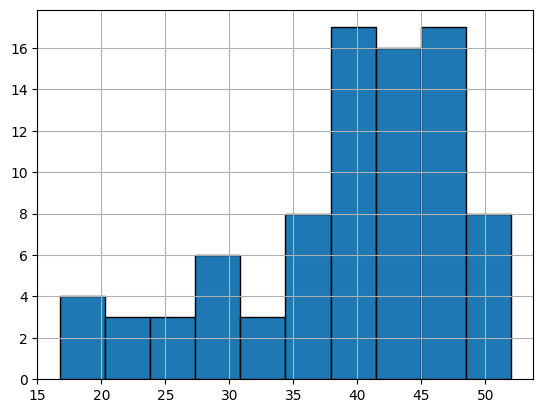

In [38]:
result["reputation_index"].hist(bins=10, edgecolor="black", xlabelsize=10, ylabelsize=10)

<Axes: >

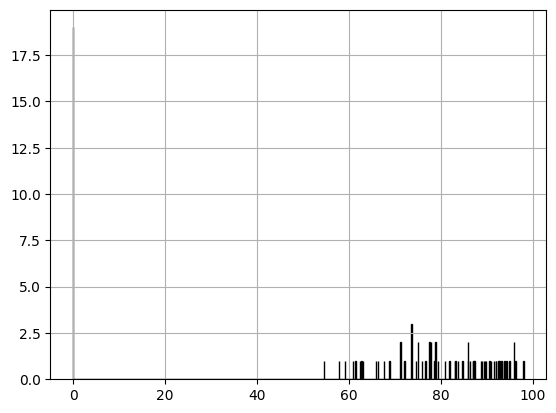

In [39]:
result['communication_score'].hist(bins=1000, edgecolor="black", xlabelsize=10, ylabelsize=10)

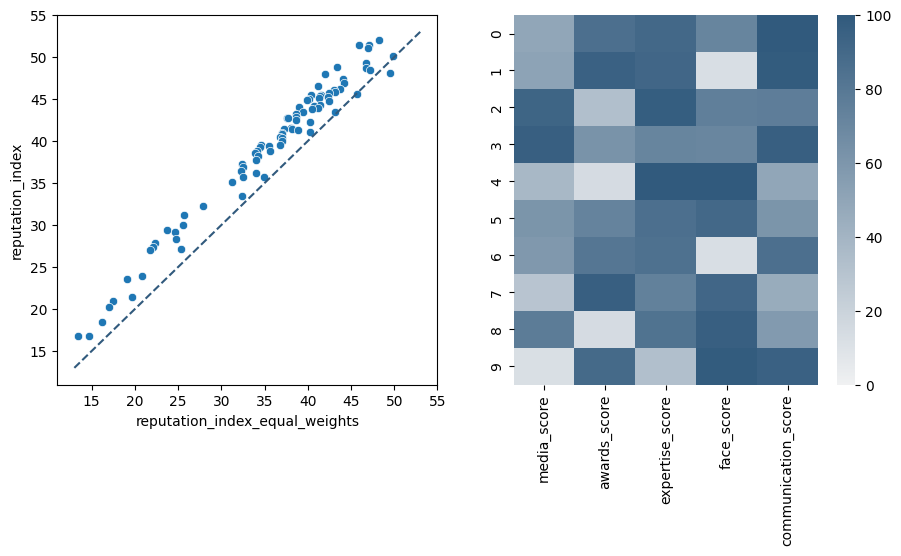

In [40]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/company_reputation_index.csv")
comp = ["media_score", "awards_score", "expertise_score", "face_score", "communication_score"]
top = df.nsmallest(10, "rank")
heat = (df[comp].rank(pct=True) * 100).loc[top.index]
rho = spearmanr(df.reputation_index, df.reputation_index_equal_weights).statistic
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.8, 4.8))
sns.scatterplot(data=df, x="reputation_index_equal_weights", y="reputation_index", ax=ax1)
ax1.plot([13, 53], [13, 53], "--", color="#315A7D")
sns.heatmap(heat, cmap=sns.light_palette("#315A7D", as_cmap=True), vmin=0, vmax=100, ax=ax2)
plt.savefig("data/reputation_robustness.png", dpi=260, bbox_inches="tight")

## Проверка связи индекса с финансовыми показателями

**Основные гипотезы**

- H1: индекс репутации положительно связан с ROA за 2025 год при контроле ROA за 2024 год и характеристик компании на конец 2024 года.
- H2: индекс репутации положительно связан с доходностью акций за 2025 год при контроле доходности за 2024 год и характеристик компании на конец 2024 года.
- H3 (исследовательская): отдельные компоненты индекса связаны с финансовыми результатами; p-value для компонентов корректируются методом Benjamini–Hochberg.
- H4: индекс улучшает объясняющую и предсказательную способность модели относительно одних контролей. Сравниваются скорректированный R², частный R² и LOOCV R²/RMSE на одной выборке.

Основная спецификация использует логарифм активов, возраст, левередж, ОС/активы, государственную собственность и исходный уровень зависимой переменной. Стандартные ошибки HC3 устойчивы к гетероскедастичности и подходят для небольшой поперечной выборки. Модель с укрупненными отраслевыми эффектами, размером по сотрудникам и винзоризацией результата служит проверкой устойчивости. Коэффициент индекса показывает изменение финансового показателя в процентных пунктах при росте индекса на 10 пунктов.

Результаты за 2024 год показывают только одновременную связь. Даже модели за 2025 год не идентифицируют причинный эффект. CAR и альфа не рассчитываются, поскольку в файле нет временных рядов котировок и доходности рыночного или отраслевого бенчмарка.

**Проверка данных:** в исходном коде алиас `HNFG → HEAD` ошибочно объединяет Henderson и HeadHunter. Если финансовый файл содержит оба тикера, неоднозначный `HEAD` исключается из объединенной выборки без пересчета индекса остальных компаний. Доходности по модулю выше 80% сохраняются отдельно для проверки сплитов и других корпоративных действий.


/var/folders/dk/cftt9_q12x391l2h1d64fnvh0000gn/T/ipykernel_47808/687572418.py:196: RuntimeWarning: divide by zero encountered in matmul
  beta = bread @ matrix.T @ y
/var/folders/dk/cftt9_q12x391l2h1d64fnvh0000gn/T/ipykernel_47808/687572418.py:196: RuntimeWarning: overflow encountered in matmul
  beta = bread @ matrix.T @ y
/var/folders/dk/cftt9_q12x391l2h1d64fnvh0000gn/T/ipykernel_47808/687572418.py:196: RuntimeWarning: invalid value encountered in matmul
  beta = bread @ matrix.T @ y
/var/folders/dk/cftt9_q12x391l2h1d64fnvh0000gn/T/ipykernel_47808/687572418.py:200: RuntimeWarning: divide by zero encountered in matmul
  meat = matrix.T @ (matrix * scaled_residuals[:, None] ** 2)
/var/folders/dk/cftt9_q12x391l2h1d64fnvh0000gn/T/ipykernel_47808/687572418.py:200: RuntimeWarning: overflow encountered in matmul
  meat = matrix.T @ (matrix * scaled_residuals[:, None] ** 2)
/var/folders/dk/cftt9_q12x391l2h1d64fnvh0000gn/T/ipykernel_47808/687572418.py:200: RuntimeWarning: invalid value encoun

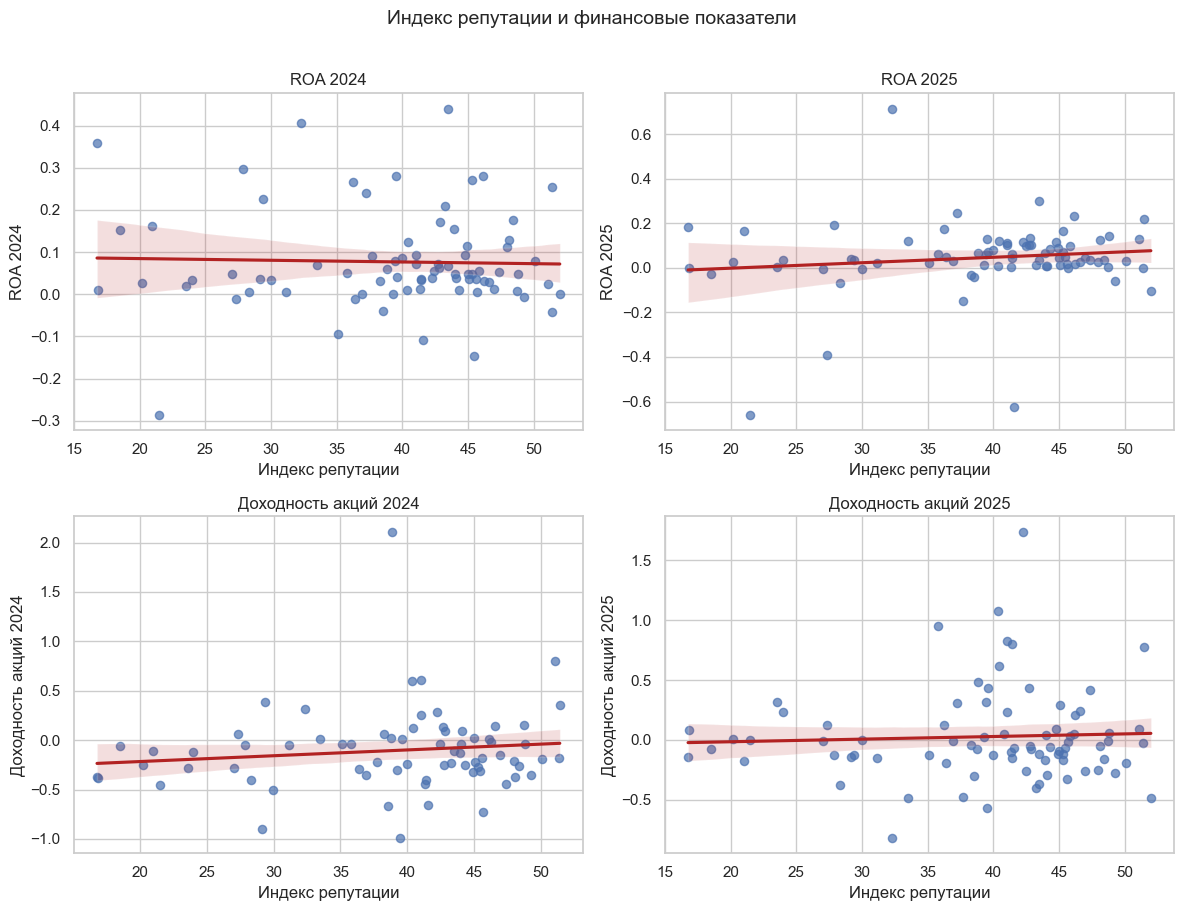

Источник индекса: переменная result из текущего ноутбука
Финансовый файл: Companies_MOEXBMI_2024_2025.xlsx
Объединено компаний: 83
Исключен HEAD из-за ошибочного алиаса HNFG → HEAD в исходном индексе.
Экстремальных доходностей |r| > 80%: 8. Проверьте сплиты и иные корпоративные действия.


,metric,value,details
0,Компаний в индексе до объединения,84,переменная result из текущего ноутбука
1,Компаний в финансовом файле до объединения,108,Companies_MOEXBMI_2024_2025.xlsx
2,Компаний в объединенной выборке,83,
3,Тикеров только в индексе,1,NVTK
4,Тикеров только в финансовом файле,25,"AGRO, APTK, ASTR, BANEP, BSPB, CBOM, CHMF, CHM..."
5,Исключено неоднозначных тикеров,1,HEAD


,outcome,model,specification,n,effect_pp_per_10_index_points,se_pp_hc3,ci_low_pp,ci_high_pp,p_value,r2,adjusted_r2,loocv_r2,loocv_rmse,significant_5pct
2,roa_2025,M3,+ финансовые контроли 2024 (основная),73,3.6926,1.7974,0.1030,7.2823,0.0440,0.5342,0.4840,0.3873,0.1157,True
7,stock_return_2025,M3,+ финансовые контроли 2024 (основная),64,2.1867,3.5420,-4.9088,9.2822,0.5395,0.3843,0.3073,0.2179,0.3324,False


,outcome,model,n_same_sample,r2,adjusted_r2,loocv_r2,loocv_rmse,partial_r2_vs_controls
0,roa_2025,Только контроли,73,0.5693,0.4831,0.2598,0.1272,0.0000
1,roa_2025,Взвешенный индекс,73,0.6208,0.5373,0.2978,0.1239,0.1198
2,roa_2025,Равные веса,73,0.6150,0.5301,0.2827,0.1252,0.1061
3,roa_2025,Пять компонентов совместно,73,0.6880,0.5916,0.3443,0.1197,0.2757
4,stock_return_2025,Только контроли,64,0.5704,0.4795,0.3406,0.3052,0.0000
5,stock_return_2025,Взвешенный индекс,64,0.5706,0.4695,0.3264,0.3085,0.0004
6,stock_return_2025,Равные веса,64,0.5705,0.4695,0.3275,0.3082,0.0004
7,stock_return_2025,Пять компонентов совместно,64,0.5758,0.4314,0.2169,0.3326,0.0126


,outcome,component,n,effect_pp_per_10_component_points,se_pp_hc3,ci_low_pp,ci_high_pp,p_value,adjusted_r2,loocv_r2,q_value_bh
2,roa_2025,expertise_score,73,2.9742,1.7611,-0.5430,6.4914,0.0960,0.4868,0.3815,0.3202
4,roa_2025,communication_score,73,0.8673,0.4417,-0.0147,1.7494,0.0538,0.4764,0.3762,0.3202
5,stock_return_2025,media_score,64,-9.3934,5.4640,-20.3390,1.5523,0.0911,0.3545,0.2529,0.3202
3,roa_2025,face_score,73,1.3177,0.9236,-0.5268,3.1622,0.1584,0.4466,0.3453,0.3961
1,roa_2025,awards_score,73,-4.4092,3.6922,-11.7831,2.9647,0.2367,0.4882,0.3288,0.4251
8,stock_return_2025,face_score,64,3.6244,3.1520,-2.6898,9.9386,0.2551,0.3206,0.2220,0.4251
9,stock_return_2025,communication_score,64,0.8201,0.9274,-1.0376,2.6778,0.3803,0.3107,0.2219,0.5433
0,roa_2025,media_score,73,0.8419,1.5223,-2.1983,3.8821,0.5821,0.4345,0.3318,0.6468
7,stock_return_2025,expertise_score,64,2.0235,3.5568,-5.1017,9.1487,0.5717,0.3082,0.2089,0.6468
6,stock_return_2025,awards_score,64,2.1091,4.6878,-7.2817,11.5000,0.6545,0.3065,0.2143,0.6545



Интерпретация коэффициента: изменение зависимой переменной в процентных пунктах при росте индекса на 10 пунктов. HC3 учитывает гетероскедастичность. Результаты показывают условную связь, а не причинный эффект.
CAR и альфа здесь не рассчитываются: для них нужен временной ряд доходностей бумаг и рыночного/отраслевого бенчмарка.


In [41]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

try:
    from IPython.display import display
except ImportError:
    display = print


OUTPUT_DIR = Path("data/index_finance_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINANCE_FILES = [
    Path("Companies_MOEXBMI_2024_2025.xlsx"),
    Path("upload/Companies_MOEXBMI_2024_2025.xlsx"),
]
INDEX_FILES = [
    Path("data/company_reputation_index.csv"),
    Path("company_reputation_index.csv"),
]


def first_existing(paths):
    return next((path for path in paths if path.exists()), None)


finance_file = first_existing(FINANCE_FILES)
if finance_file is None:
    raise FileNotFoundError(
        "Положите Companies_MOEXBMI_2024_2025.xlsx рядом с ноутбуком."
    )

if "result" in globals() and isinstance(result, pd.DataFrame):
    reputation = result.copy()
    index_source = "переменная result из текущего ноутбука"
else:
    index_file = first_existing(INDEX_FILES)
    if index_file is None:
        raise FileNotFoundError(
            "Сначала выполните ячейку расчета индекса или создайте "
            "data/company_reputation_index.csv."
        )
    reputation = pd.read_csv(index_file)
    index_source = str(index_file)


rename_columns = {
    "Краткое наименование": "company_finance",
    "Возраст компании, лет": "age",
    "Вид деятельности/отрасль": "industry_raw",
    "Тикер биржевой": "ticker_raw",
    "2024, Среднесписочная численность работников": "employees_2024",
    "2025, Среднесписочная численность работников": "employees_2025",
    "2024, Основные средства, рубли": "fixed_assets_2024",
    "2025, Основные средства, рубли": "fixed_assets_2025",
    "2024, Активы, рубли": "assets_2024",
    "2025, Активы, рубли": "assets_2025",
    "2024, Совокупный долг, рубли": "debt_2024",
    "2025, Совокупный долг, рубли": "debt_2025",
    "2024, Рентабельность активов (ROA)": "roa_2024",
    "2025, Рентабельность активов (ROA)": "roa_2025",
    "2024, Доходность акций": "stock_return_2024",
    "2025, Доходность акций": "stock_return_2025",
    "2024, Дамми на гос. Собственность": "state_2024",
    "2025, Дамми на гос. Собственность": "state_2025",
    "2024, Финансовый рычаг": "leverage_2024",
    "2025, Финансовый рычаг": "leverage_2025",
    "2024, ОС/Активы": "fixed_assets_ratio_2024",
    "2025, ОС/Активы": "fixed_assets_ratio_2025",
}

finance = pd.read_excel(finance_file).rename(columns=rename_columns)


def canonical_ticker(value):
    if pd.isna(value):
        return pd.NA
    aliases = {"YNDX": "YDEX", "T": "TCSG"}
    parts = [part.strip() for part in re.split(r"[,;/|]+", str(value).upper())]
    parts = [aliases.get(part, part) for part in parts if part]
    parts = list(dict.fromkeys(parts))
    return parts[0] if len(parts) == 1 else ", ".join(parts)


finance["ticker"] = finance["ticker_raw"].map(canonical_ticker)
reputation["ticker"] = reputation["Ticker"].map(canonical_ticker)

# В исходном index_0.ipynb HNFG ошибочно заменяется на HEAD, хотя это
# Henderson и HeadHunter. Если обе бумаги есть в финансах, HEAD исключается.
raw_tickers = set(finance["ticker_raw"].astype(str).str.upper().str.strip())
ambiguous_tickers = {"HEAD"} if {"HEAD", "HNFG"} <= raw_tickers else set()

finance = finance[~finance["ticker"].isin(ambiguous_tickers)].copy()
reputation = reputation[~reputation["ticker"].isin(ambiguous_tickers)].copy()

for name, frame in {"индексе": reputation, "финансовых данных": finance}.items():
    duplicates = frame.loc[frame["ticker"].duplicated(False), "ticker"].dropna().unique()
    if len(duplicates):
        raise ValueError(f"Дубли тикеров в {name}: {', '.join(duplicates)}")

index_columns = [
    "reputation_index",
    "reputation_index_equal_weights",
    "media_score",
    "awards_score",
    "expertise_score",
    "face_score",
    "communication_score",
]
missing_index_columns = [column for column in index_columns if column not in reputation]
if missing_index_columns:
    raise KeyError(f"В индексе нет колонок: {missing_index_columns}")

merged = reputation.merge(finance, on="ticker", how="inner", validate="one_to_one")
index_only = sorted(set(reputation["ticker"].dropna()) - set(finance["ticker"].dropna()))
finance_only = sorted(set(finance["ticker"].dropna()) - set(reputation["ticker"].dropna()))

numeric_columns = [
    "age", "employees_2024", "employees_2025", "assets_2024", "assets_2025",
    "roa_2024", "roa_2025", "stock_return_2024", "stock_return_2025",
    "state_2024", "state_2025", "leverage_2024", "leverage_2025",
    "fixed_assets_ratio_2024", "fixed_assets_ratio_2025", *index_columns,
]
for column in numeric_columns:
    merged[column] = pd.to_numeric(merged[column], errors="coerce")

merged["log_assets_2024"] = np.log(merged["assets_2024"].where(merged["assets_2024"] > 0))
merged["log_employees_2024"] = np.log(
    merged["employees_2024"].where(merged["employees_2024"] > 0)
)
merged["roa_change_2025"] = merged["roa_2025"] - merged["roa_2024"]
merged["stock_return_change_2025"] = (
    merged["stock_return_2025"] - merged["stock_return_2024"]
)

for column in index_columns:
    merged[f"{column}_10"] = merged[column] / 10

industry_counts = merged["industry_raw"].value_counts()
merged["industry_group"] = merged["industry_raw"].where(
    merged["industry_raw"].map(industry_counts).ge(3), "Прочие"
).fillna("Не указана")


def winsorize(series, lower=0.01, upper=0.99):
    limits = series.quantile([lower, upper])
    return series.clip(limits.iloc[0], limits.iloc[1])


merged["roa_2025_w"] = winsorize(merged["roa_2025"])
merged["stock_return_2025_w"] = winsorize(merged["stock_return_2025"])


def bh_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    valid = np.isfinite(p)
    adjusted = np.full(len(p), np.nan)
    if not valid.any():
        return adjusted
    values = p[valid]
    order = np.argsort(values)
    ranked = values[order] * len(values) / np.arange(1, len(values) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1].clip(max=1)
    restored = np.empty_like(ranked)
    restored[order] = ranked
    adjusted[valid] = restored
    return adjusted


def fit_ols(data, outcome, predictors, categorical=()):
    columns = [outcome, *predictors, *categorical]
    sample = data[columns].dropna().copy()
    x = pd.get_dummies(
        sample[[*predictors, *categorical]],
        columns=list(categorical),
        drop_first=True,
        dtype=float,
    )
    varying = [column for column in x if x[column].nunique() > 1]
    x = x[varying].astype(float)
    x.insert(0, "Intercept", 1.0)
    y = sample[outcome].to_numpy(float)
    matrix = x.to_numpy(float)
    n = len(y)
    rank = np.linalg.matrix_rank(matrix)
    if n <= rank + 2:
        raise ValueError(f"Слишком мало наблюдений для {outcome}: N={n}, rank={rank}")

    bread = np.linalg.pinv(matrix.T @ matrix)
    beta = bread @ matrix.T @ y
    residuals = y - matrix @ beta
    leverage = np.einsum("ij,jk,ik->i", matrix, bread, matrix).clip(max=1 - 1e-10)
    scaled_residuals = residuals / (1 - leverage)
    meat = matrix.T @ (matrix * scaled_residuals[:, None] ** 2)
    vcov_hc3 = bread @ meat @ bread
    se = np.sqrt(np.maximum(np.diag(vcov_hc3), 0))
    df_resid = n - rank
    t_values = np.divide(beta, se, out=np.full_like(beta, np.nan), where=se > 0)
    p_values = 2 * stats.t.sf(np.abs(t_values), df_resid)
    critical = stats.t.ppf(0.975, df_resid)
    sse = float(residuals @ residuals)
    sst = float(((y - y.mean()) ** 2).sum())
    r2 = 1 - sse / sst if sst else np.nan
    adj_r2 = 1 - (1 - r2) * (n - 1) / df_resid if np.isfinite(r2) else np.nan
    press_residuals = residuals / (1 - leverage)
    cv_sse = float(press_residuals @ press_residuals)

    table = pd.DataFrame({
        "term": x.columns,
        "coef": beta,
        "se_hc3": se,
        "t": t_values,
        "p_value": p_values,
        "ci_low": beta - critical * se,
        "ci_high": beta + critical * se,
    })
    return {
        "table": table,
        "n": n,
        "rank": rank,
        "r2": r2,
        "adj_r2": adj_r2,
        "sse": sse,
        "cv_r2": 1 - cv_sse / sst if sst else np.nan,
        "cv_rmse": np.sqrt(cv_sse / n),
    }


index_term = "reputation_index_10"
controls_2024 = [
    "log_assets_2024", "age", "leverage_2024",
    "fixed_assets_ratio_2024", "state_2024",
]

regression_rows = []


def add_index_result(outcome, model, label, predictors, categorical=()):
    fitted = fit_ols(merged, outcome, predictors, categorical)
    row = fitted["table"].set_index("term").loc[index_term]
    regression_rows.append({
        "outcome": outcome,
        "model": model,
        "specification": label,
        "n": fitted["n"],
        "effect_pp_per_10_index_points": row["coef"] * 100,
        "se_pp_hc3": row["se_hc3"] * 100,
        "ci_low_pp": row["ci_low"] * 100,
        "ci_high_pp": row["ci_high"] * 100,
        "p_value": row["p_value"],
        "r2": fitted["r2"],
        "adjusted_r2": fitted["adj_r2"],
        "loocv_r2": fitted["cv_r2"],
        "loocv_rmse": fitted["cv_rmse"],
    })


for outcome, lag in [
    ("roa_2025", "roa_2024"),
    ("stock_return_2025", "stock_return_2024"),
]:
    add_index_result(outcome, "M1", "Без контролей", [index_term])
    add_index_result(outcome, "M2", "+ исходный уровень 2024", [index_term, lag])
    add_index_result(
        outcome, "M3", "+ финансовые контроли 2024 (основная)",
        [index_term, lag, *controls_2024],
    )
    add_index_result(
        outcome, "M4", "+ укрупненные отраслевые эффекты",
        [index_term, lag, *controls_2024], ["industry_group"],
    )
    employee_controls = [
        "log_employees_2024" if x == "log_assets_2024" else x
        for x in controls_2024
    ]
    add_index_result(
        outcome, "M5", "Размер по сотрудникам вместо активов",
        [index_term, lag, *employee_controls],
    )

for outcome in ["roa_2024", "stock_return_2024"]:
    add_index_result(
        outcome, "C2024", "Одновременная связь в 2024 году",
        [index_term, *controls_2024],
    )

for outcome, lag in [
    ("roa_2025_w", "roa_2024"),
    ("stock_return_2025_w", "stock_return_2024"),
]:
    add_index_result(
        outcome, "W2025", "Винзоризация зависимой переменной 1–99%",
        [index_term, lag, *controls_2024],
    )

regression_results = pd.DataFrame(regression_rows)


component_rows = []
component_terms = [f"{column}_10" for column in index_columns[2:]]
for outcome, lag in [
    ("roa_2025", "roa_2024"),
    ("stock_return_2025", "stock_return_2024"),
]:
    for term in component_terms:
        fitted = fit_ols(merged, outcome, [term, lag, *controls_2024])
        row = fitted["table"].set_index("term").loc[term]
        component_rows.append({
            "outcome": outcome,
            "component": term.removesuffix("_10"),
            "n": fitted["n"],
            "effect_pp_per_10_component_points": row["coef"] * 100,
            "se_pp_hc3": row["se_hc3"] * 100,
            "ci_low_pp": row["ci_low"] * 100,
            "ci_high_pp": row["ci_high"] * 100,
            "p_value": row["p_value"],
            "adjusted_r2": fitted["adj_r2"],
            "loocv_r2": fitted["cv_r2"],
        })

component_results = pd.DataFrame(component_rows)
component_results["q_value_bh"] = bh_adjust(component_results["p_value"])


comparison_rows = []
comparison_specs = {
    "Только контроли": [],
    "Взвешенный индекс": ["reputation_index_10"],
    "Равные веса": ["reputation_index_equal_weights_10"],
    "Пять компонентов совместно": component_terms,
}
for outcome, lag in [
    ("roa_2025", "roa_2024"),
    ("stock_return_2025", "stock_return_2024"),
]:
    required = [outcome, lag, *controls_2024, "industry_group", *component_terms,
                "reputation_index_10", "reputation_index_equal_weights_10"]
    common_sample = merged.dropna(subset=required).copy()
    base_fit = None
    for model_name, added in comparison_specs.items():
        fitted = fit_ols(
            common_sample, outcome, [lag, *controls_2024, *added], ["industry_group"]
        )
        if base_fit is None:
            base_fit = fitted
        comparison_rows.append({
            "outcome": outcome,
            "model": model_name,
            "n_same_sample": fitted["n"],
            "r2": fitted["r2"],
            "adjusted_r2": fitted["adj_r2"],
            "loocv_r2": fitted["cv_r2"],
            "loocv_rmse": fitted["cv_rmse"],
            "partial_r2_vs_controls": (
                (base_fit["sse"] - fitted["sse"]) / base_fit["sse"]
                if model_name != "Только контроли" else 0
            ),
        })

model_comparison = pd.DataFrame(comparison_rows)


correlation_rows = []
correlation_predictors = index_columns
correlation_outcomes = ["roa_2024", "roa_2025", "stock_return_2024", "stock_return_2025"]
for predictor in correlation_predictors:
    for outcome in correlation_outcomes:
        sample = merged[[predictor, outcome]].dropna()
        for method, function in [("Pearson", stats.pearsonr), ("Spearman", stats.spearmanr)]:
            estimate, p_value = function(sample[predictor], sample[outcome])
            correlation_rows.append({
                "predictor": predictor,
                "outcome": outcome,
                "method": method,
                "n": len(sample),
                "correlation": estimate,
                "p_value": p_value,
            })

correlations = pd.DataFrame(correlation_rows)
correlations["q_value_bh"] = correlations.groupby("method")["p_value"].transform(bh_adjust)


suspicious_returns = merged.loc[
    merged[["stock_return_2024", "stock_return_2025"]]
    .abs().gt(0.80).any(axis=1),
    ["ticker", "Company", "stock_return_2024", "stock_return_2025"],
].copy()

audit = pd.DataFrame({
    "metric": [
        "Компаний в индексе до объединения",
        "Компаний в финансовом файле до объединения",
        "Компаний в объединенной выборке",
        "Тикеров только в индексе",
        "Тикеров только в финансовом файле",
        "Исключено неоднозначных тикеров",
    ],
    "value": [
        len(reputation), len(finance), len(merged), len(index_only), len(finance_only),
        len(ambiguous_tickers),
    ],
    "details": [
        index_source, str(finance_file), "", ", ".join(index_only),
        ", ".join(finance_only), ", ".join(sorted(ambiguous_tickers)),
    ],
})

merged.to_csv(OUTPUT_DIR / "merged_index_finance.csv", index=False, encoding="utf-8-sig")
audit.to_csv(OUTPUT_DIR / "sample_audit.csv", index=False, encoding="utf-8-sig")
regression_results.to_csv(OUTPUT_DIR / "regression_results.csv", index=False, encoding="utf-8-sig")
component_results.to_csv(OUTPUT_DIR / "component_results_fdr.csv", index=False, encoding="utf-8-sig")
model_comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")
correlations.to_csv(OUTPUT_DIR / "correlations.csv", index=False, encoding="utf-8-sig")
suspicious_returns.to_csv(OUTPUT_DIR / "suspicious_returns.csv", index=False, encoding="utf-8-sig")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, outcome, title in zip(
    axes.flat,
    correlation_outcomes,
    ["ROA 2024", "ROA 2025", "Доходность акций 2024", "Доходность акций 2025"],
):
    sns.regplot(
        data=merged, x="reputation_index", y=outcome, ax=ax,
        scatter_kws={"alpha": 0.7, "s": 35}, line_kws={"color": "#B22222"},
    )
    ax.set(title=title, xlabel="Индекс репутации", ylabel=title)
fig.suptitle("Индекс репутации и финансовые показатели", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "index_finance_scatter.png", dpi=220, bbox_inches="tight")
plt.show()

primary = regression_results.query("model == 'M3'").copy()
primary["significant_5pct"] = primary["p_value"] < 0.05

print(f"Источник индекса: {index_source}")
print(f"Финансовый файл: {finance_file}")
print(f"Объединено компаний: {len(merged)}")
if ambiguous_tickers:
    print("Исключен HEAD из-за ошибочного алиаса HNFG → HEAD в исходном индексе.")
if len(suspicious_returns):
    print(
        f"Экстремальных доходностей |r| > 80%: {len(suspicious_returns)}. "
        "Проверьте сплиты и иные корпоративные действия."
    )

display(audit)
display(primary.round(4))
display(model_comparison.round(4))
display(component_results.sort_values("q_value_bh").round(4))

print(
    "\nИнтерпретация коэффициента: изменение зависимой переменной в процентных "
    "пунктах при росте индекса на 10 пунктов. HC3 учитывает гетероскедастичность. "
    "Результаты показывают условную связь, а не причинный эффект."
)
print(
    "CAR и альфа здесь не рассчитываются: для них нужен временной ряд доходностей "
    "бумаг и рыночного/отраслевого бенчмарка."
)


In [43]:
from catboost import CatBoostRegressor, Pool
import numpy as np
import pandas as pd

components = ["media_score", "awards_score", "expertise_score",
              "face_score", "communication_score"]

controls = ["roa_2024", "log_assets_2024", "age",
            "leverage_2024", "fixed_assets_ratio_2024", "state_2024"]

d = merged[["roa_2025", *components, *controls]].dropna()

X, y = d[components + controls], d["roa_2025"]

model = CatBoostRegressor(iterations=500, depth=3, learning_rate=.03,
                          loss_function="RMSE", verbose=False, random_seed=42)
model.fit(X, y)

shap = model.get_feature_importance(Pool(X, y), type="ShapValues")[:, :-1]

importance = pd.Series(np.abs(shap).mean(0), index=X.columns)
weights = importance[components] / importance[components].sum()

print(weights.sort_values(ascending=False))

merged["reputation_index_catboost"] = (
    merged[components] * weights
).sum(axis=1)

print(pd.DataFrame({
    "weight": weights,
    "mean_abs_SHAP": importance[components]
}).sort_values("weight", ascending=False))

expertise_score        0.411204
communication_score    0.281831
awards_score           0.171575
media_score            0.079749
face_score             0.055641
dtype: float64
                       weight  mean_abs_SHAP
expertise_score      0.411204       0.020326
communication_score  0.281831       0.013931
awards_score         0.171575       0.008481
media_score          0.079749       0.003942
face_score           0.055641       0.002750


In [46]:
# новые веса
weights = {
    "expertise_score": 0.411204,
    "communication_score": 0.281831,
    "awards_score": 0.171575,
    "media_score": 0.079749,
    "face_score": 0.055641
}

# новый индекс
merged["index_catboost"] = sum(
    merged[col] * w for col, w in weights.items()
)

# регрессии
import statsmodels.formula.api as smf

controls = "roa_2024 + log_assets_2024 + age + leverage_2024 + fixed_assets_ratio_2024 + state_2024"

m_roa = smf.ols(
    f"roa_2025 ~ I(index_catboost / 10) + {controls}",
    data=merged
).fit(cov_type="HC3")

m_return = smf.ols(
    "stock_return_2025 ~ I(index_catboost / 10) + stock_return_2024 + "
    "log_assets_2024 + age + leverage_2024 + fixed_assets_ratio_2024 + state_2024",
    data=merged
).fit(cov_type="HC3")

print(m_roa.summary())
print(m_return.summary())

                            OLS Regression Results                            
Dep. Variable:               roa_2025   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     4.240
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           0.000659
Time:                        15:32:05   Log-Likelihood:                 64.832
No. Observations:                  73   AIC:                            -113.7
Df Residuals:                      65   BIC:                            -95.34
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tools/tools.py:274: RuntimeWarning: divide by zero encountered in dot
  res = np.dot(np.transpose(vt), np.multiply(s[:, np.newaxis],
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tools/tools.py:274: RuntimeWarning: overflow encountered in dot
  res = np.dot(np.transpose(vt), np.multiply(s[:, np.newaxis],
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tools/tools.py:274: RuntimeWarning: invalid value encountered in dot
  res = np.dot(np.transpose(vt), np.multiply(s[:, np.newaxis],
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1970: RuntimeWarning: divide by zero encountered in dot
  H = np.dot(self.model.pinv_wexog,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:19

In [47]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import LeaveOneOut
import numpy as np
import pandas as pd

components = [
    "media_score", "awards_score", "expertise_score",
    "face_score", "communication_score"
]

controls = [
    "log_assets_2024", "age", "leverage_2024",
    "fixed_assets_ratio_2024", "state_2024"
]

y = "roa_2025"
lag = "roa_2024"

# одна и та же выборка для всех моделей
cols = [
    y, lag, *controls, "industry_group",
    "reputation_index", "reputation_index_equal_weights",
    *components
]
d = merged[cols].dropna().copy()

# отраслевые dummy — как в Таблице 4
ind = pd.get_dummies(
    d["industry_group"], prefix="ind",
    drop_first=True, dtype=float
)
d = pd.concat([d, ind], axis=1)
industry_cols = list(ind.columns)


# ---------- CatBoost -> SHAP-веса ----------
def get_cb_weights(train):
    features = components + [lag, *controls, "industry_group"]
    X = train[features]

    model = CatBoostRegressor(
        iterations=500,
        depth=3,
        learning_rate=.03,
        loss_function="RMSE",
        verbose=False,
        random_seed=42
    )

    model.fit(X, train[y], cat_features=["industry_group"])

    shap = model.get_feature_importance(
        Pool(X, train[y], cat_features=["industry_group"]),
        type="ShapValues"
    )[:, :-1]

    imp = pd.Series(
        np.abs(shap).mean(axis=0),
        index=features
    )[components]

    return imp / imp.sum()


# ---------- обычная OLS ----------
def ols(train, test, added):
    predictors = [lag, *controls, *industry_cols, *added]

    X1 = np.column_stack([
        np.ones(len(train)),
        train[predictors].to_numpy(float)
    ])
    X2 = np.column_stack([
        np.ones(len(test)),
        test[predictors].to_numpy(float)
    ])

    beta = np.linalg.lstsq(
        X1, train[y].to_numpy(float), rcond=None
    )[0]

    return X2 @ beta


# ---------- веса на полной выборке ----------
w_full = get_cb_weights(d)

d["index_catboost"] = d[components].dot(w_full)
merged["index_catboost"] = merged[components].dot(w_full)

print("CATBOOST WEIGHTS")
print(w_full.sort_values(ascending=False))


# ---------- in-sample ----------
specs = {
    "Только контроли": [],
    "Равные веса": ["reputation_index_equal_weights"],
    "Исходный индекс": ["reputation_index"],
    "CatBoost-SHAP индекс": ["index_catboost"],
    "Пять компонентов": components
}

rows = []

for name, added in specs.items():
    pred = ols(d, d, added)
    actual = d[y].to_numpy()

    sse = np.sum((actual - pred) ** 2)
    sst = np.sum((actual - actual.mean()) ** 2)
    r2 = 1 - sse / sst

    k = 1 + len([lag, *controls, *industry_cols, *added])
    adj_r2 = 1 - (1-r2) * (len(d)-1) / (len(d)-k)

    rows.append([name, r2, adj_r2])


# ---------- честный LOOCV ----------
loo = LeaveOneOut()

predictions = {name: [] for name in specs}
fold_weights = []

for train_i, test_i in loo.split(d):

    train = d.iloc[train_i].copy()
    test = d.iloc[test_i].copy()

    # фиксированные модели
    for name in [
        "Только контроли",
        "Равные веса",
        "Исходный индекс",
        "Пять компонентов"
    ]:
        predictions[name].append(
            ols(train, test, specs[name])[0]
        )

    # CatBoost-веса заново только на train
    w = get_cb_weights(train)
    fold_weights.append(w)

    train["index_cb_fold"] = train[components].dot(w)
    test["index_cb_fold"] = test[components].dot(w)

    predictions["CatBoost-SHAP индекс"].append(
        ols(train, test, ["index_cb_fold"])[0]
    )


actual = d[y].to_numpy()
sst = np.sum((actual - actual.mean()) ** 2)

result = pd.DataFrame(rows, columns=[
    "Model", "R2", "Adj_R2"
])

for name in specs:
    pred = np.array(predictions[name])

    result.loc[result.Model == name, "LOOCV_R2"] = (
        1 - np.sum((actual - pred) ** 2) / sst
    )

    result.loc[result.Model == name, "LOOCV_RMSE"] = (
        np.sqrt(np.mean((actual - pred) ** 2))
    )

print("\nMODEL COMPARISON")
print(result.round(4))


# ---------- стабильность CatBoost-весов ----------
fold_weights = pd.DataFrame(fold_weights)

weight_stability = pd.DataFrame({
    "full_sample_weight": w_full,
    "LOOCV_mean_weight": fold_weights.mean(),
    "LOOCV_sd": fold_weights.std(),
    "LOOCV_min": fold_weights.min(),
    "LOOCV_max": fold_weights.max()
}).sort_values("full_sample_weight", ascending=False)

print("\nWEIGHT STABILITY")
print(weight_stability.round(4))

CATBOOST WEIGHTS
expertise_score        0.404223
communication_score    0.274273
awards_score           0.187147
media_score            0.084325
face_score             0.050032
dtype: float64


/var/folders/dk/cftt9_q12x391l2h1d64fnvh0000gn/T/ipykernel_47808/780769509.py:82: RuntimeWarning: divide by zero encountered in matmul
  return X2 @ beta
/var/folders/dk/cftt9_q12x391l2h1d64fnvh0000gn/T/ipykernel_47808/780769509.py:82: RuntimeWarning: overflow encountered in matmul
  return X2 @ beta
/var/folders/dk/cftt9_q12x391l2h1d64fnvh0000gn/T/ipykernel_47808/780769509.py:82: RuntimeWarning: invalid value encountered in matmul
  return X2 @ beta



MODEL COMPARISON
                  Model      R2  Adj_R2  LOOCV_R2  LOOCV_RMSE
0       Только контроли  0.5693  0.4831    0.2598      0.1272
1           Равные веса  0.6150  0.5301    0.2827      0.1252
2       Исходный индекс  0.6208  0.5373    0.2978      0.1239
3  CatBoost-SHAP индекс  0.6268  0.5446    0.2821      0.1253
4      Пять компонентов  0.6880  0.5916    0.3443      0.1197

WEIGHT STABILITY
                     full_sample_weight  LOOCV_mean_weight  LOOCV_sd  \
expertise_score                  0.4042             0.4299    0.0381   
communication_score              0.2743             0.2970    0.0285   
awards_score                     0.1871             0.1655    0.0245   
media_score                      0.0843             0.0568    0.0110   
face_score                       0.0500             0.0508    0.0163   

                     LOOCV_min  LOOCV_max  
expertise_score         0.2446     0.5406  
communication_score     0.2275     0.4160  
awards_score            0.1